# hrc-s exposure map

In [1]:
source /export/ciao/bin/ciao.bash -o
PFILES="./param;$ASCDS_INSTALL/param:$ASCDS_INSTALL/contrib/param"
mkdir -p ./param
ASCDS_WORK_PATH=./


CIAO configuration is complete... 
CIAO 4.9 Friday, December  2, 2016
  bindir      : /export/ciao-4.9/bin
  CALDB       : 4.7.3


## download

In [2]:
/bin/rm -rf 1038
download_chandra_obsid 1038 


  Type     Format      Size  0........H.........1  Download Time Average Rate
  ---------------------------------------------------------------------------
  readme   ascii      10 Kb  ####################          < 1 s  1779.3 kb/s
  oif      fits       23 Kb  ####################          < 1 s  3624.4 kb/s
  vv       pdf        30 Kb  ####################          < 1 s  4604.9 kb/s
  cntr_img fits      421 Kb  ####################          < 1 s  21315.6 kb/s
  cntr_img jpg       938 Kb  ####################          < 1 s  32928.7 kb/s
  evt2     fits      173 Mb  ####################            2 s  84115.7 kb/s
  full_img fits       71 Kb  ####################          < 1 s  8216.4 kb/s
  full_img jpg        21 Kb  ####################          < 1 s  3270.7 kb/s
  dtf      fits      182 Kb  ####################          < 1 s  15625.4 kb/s
  fov      fits        4 Kb  ####################          < 1 s  787.5 kb/s
  eph1     fits      281 Kb  ####################          <

In [3]:
/bin/rm -rf repro
chandra_repro 1038 `pwd`/repro 


Processing input directory '/data/sdsreg/thread_output/CIAO4.9/expmap_hrcs/1038'


Running hrc_build_badpix to create new bad pixel file...

Running hrc_process_events to reprocess the evt1.fits file...
Output from hrc_process_events:
# hrc_process_events (CIAO 4.9): The following error occurred 2216 times:

# hrc_process_events (CIAO 4.9): The following error occurred 14 times:
	dsHPEEVENTSEQERR -- WARNING: Out of sequence events discovered in /data/sdsreg/thread_output/CIAO4.9/expmap_hrcs/1038/secondary/hrcf01038_000N004_evt1.fits.
Filtering the evt1.fits file on grade and status...
Applying the good time intervals from the flt1.fits file...

Running hrc_dtfstats to recompute the average dead time corrections...
The new level=2 event file is: /data/sdsreg/thread_output/CIAO4.9/expmap_hrcs/repro/hrcf01038_repro_evt2.fits

Updating the event file header with chandra_repro HISTORY record
Creating FOV file...
Setting observation-specific bad pixel file in local ardlib.par.

Cleaning up 

## Run `fluximage`

In [4]:
fluximage repro/ casa bands=::1.1 binsize=16 clob+

Running fluximage
Version: 12 September 2016

Found repro/hrcf01038_repro_evt2.fits
Using event file repro/hrcf01038_repro_evt2.fits
Using PI=: with a monochromatic energy of 1.1 keV.
Aspect solution repro/pcadf117263575N003_asol1.fits found.
Bad-pixel file repro/hrcf01038_repro_bpix1.fits found.
Mask file repro/hrcf01038_000N004_msk1.fits found.
Dtf file repro/hrcf01038_000N004_dtf1.fits found.

The output images will have 991 by 317 pixels, pixel size of 2.1088 arcsec,
    and cover x=23984.5:39840.5:16,y=30224.5:35296.5:16.

Running tasks in parallel with 4 processors.
Creating aspect histogram for obsid 1038
# asphist (CIAO 4.9): WARNING: skipping 35 livetime correction records (from time: 117263850.466868 to time: 117263920.166871)


Creating instrument map for obsid 1038
Creating exposure map for obsid 1038
Thresholding data for obsid 1038
Exposure-correcting image for obsid 1038

The following files were created:

 The clipped counts image is:
     casa_all_thresh.img

 The clip

---
## Step-by-step

### Create image

In [5]:
dmcopy "repro/hrcf01038_repro_evt2.fits[sky=region(repro/hrcf01038_repro_fov1.fits)][bin sky=::16]" img.bin16 clob+

### asphist

In [6]:
cat repro/hrcf01038_asol1.lis

/data/sdsreg/thread_output/CIAO4.9/expmap_hrcs/1038/primary/pcadf117263575N003_asol1.fits


In [7]:
asphist @-repro/hrcf01038_asol1.lis asphist.fits \
   repro/hrcf01038_repro_evt2.fits repro/hrcf01038_000N004_dtf1.fits clob+

# asphist (CIAO 4.9): WARNING: skipping 35 livetime correction records (from time: 117263850.466868 to time: 117263920.166871)




### instmap

In [8]:
pset mkinstmap pixelgrid="1:16384:#1024,1:16384:#1024"
pset mkinstmap obsfile="repro/hrcf01038_repro_evt2.fits"
pset mkinstmap maskfile="repro/hrcf01038_000N004_msk1.fits"
pset mkinstmap detsubsys=HRC-S2
pset mkinstmap outfile=2.instmap 
pset mkinstmap spectrum=NONE monoenergy=1.1 
mkinstmap mode=h clob+

### Expmap

In [9]:
get_sky_limits img.bin16

Running: get_sky_limits
  version: 07 October 2016
Checking binning of image: img.bin16
  Image has 991 x 316 pixels
  Pixel size is 16.0 by 16.0
  Lower left (0.5,0.5) corner is x,y= 23984.9, 30235.9
  Upper right (991.5,316.5) corner is x,y= 39840.9, 35291.9
  DM filter is:
    x=23984.9:39840.9:#991,y=30235.9:35291.9:#316
  mkexpmap xygrid value is:
    23984.9:39840.9:#991,30235.9:35291.9:#316


In [10]:
pset mkexpmap xygrid=")get_sky_limits.xygrid"
pset mkexpmap normalize=no
pset mkexpmap asp=asphist.fits 
pset mkexpmap outfile=expmap.bin16 
pset mkexpmap inst=2.instmap 
mkexpmap mode=h clob+

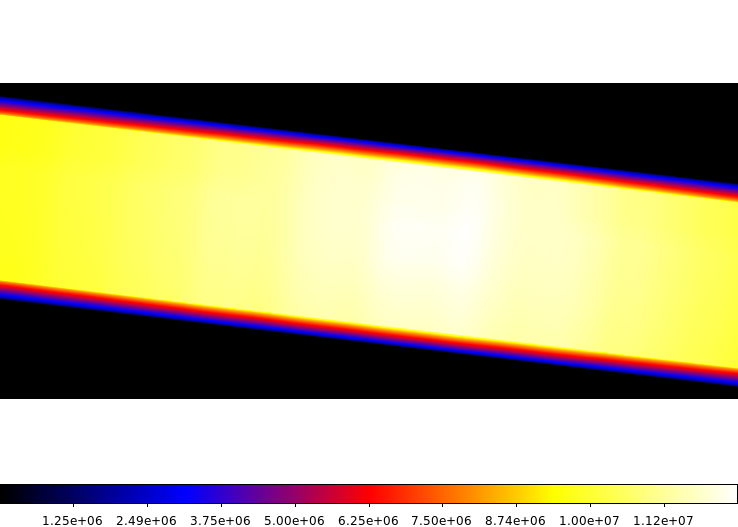

In [11]:
ds9 expmap.bin16 -cmap b -saveimage png ds9_01.png -quit
display < ds9_01.png

### Threshold

In [12]:
dmimgthresh img.bin16 img.thresh.bin16 expfile=expmap.bin16 cut=1.5% clob+
dmimgthresh expmap.bin16 expmap.thresh.bin16 cut=1.5% clob+

### Normalize aka Divide

In [13]:
dmimgcalc img.thresh.bin16 expmap.thresh.bin16 norm.bin16 div clob+

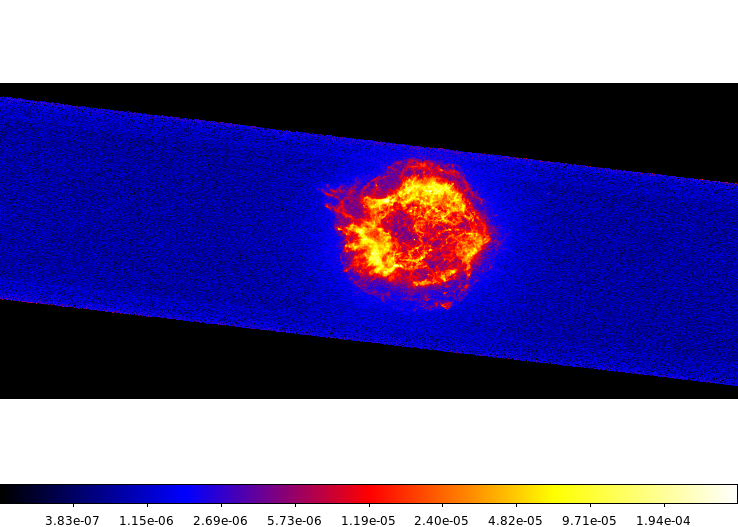

In [14]:
ds9 norm.bin16 -cmap b -scale log -saveimage png ds9_02.png -quit
display < ds9_02.png

# Cleanup

In [ ]:
/bin/rm -rf 1038 repro 